# Willkomen in das Quarto-Buch

This is the main page of the Quarto book. More content will be added here.

In [2]:
import pandas as pd;
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# brauchts für die HeatMap
def lv95_to_wgs84(E, N):
    y = (E - 2600000.0) / 1000000.0
    x = (N - 1200000.0) / 1000000.0
    lat = 16.9023892 + 3.238272 * x - 0.270978 * y**2 - 0.002528 * x**2 - 0.0447 * y**2 * x - 0.0140 * x**3
    lon = 2.6779094 + 4.728982 * y + 0.791484 * y * x + 0.1306 * y * x**2 - 0.0436 * y**3
    lat = lat * 100/36
    lon = lon * 100/36
    return lat, lon

df_zug_schweiz = pd.read_csv("data/stop-points-today_Schweiz.csv", sep=";", dtype=str)
df_zug_schweiz["E-Koordinate"] = df_zug_schweiz["E-Koordinate"].astype(float)
df_zug_schweiz["N-Koordinate"] = df_zug_schweiz["N-Koordinate"].astype(float)

# LV95 zu WGS84 Umrechnung wegen LV95 fast nur Schweiz ist
df_zug_schweiz["lat"], df_zug_schweiz["lon"] = zip(*df_zug_schweiz.apply(lambda row: lv95_to_wgs84(row["E-Koordinate"], row["N-Koordinate"]), axis=1))

fig = px.density_map(
    df_zug_schweiz,
    lat="lat",
    lon="lon",
    radius=4.5,
    center={"lat":46.70, "lon":8.3},
    zoom=7,
    map_style="open-street-map",
    opacity=0.3,
    title="Heatmap der Haltestellen in der Schweiz",
    width=1000,
    height=750,
    color_continuous_scale="viridis"
)
fig.show()

In [79]:
df_zug_zurich = pd.read_csv("data/stop-points-today_zurich.csv", sep=";", dtype=str)
df_zug_zurich["E-Koordinate"] = df_zug_zurich["E-Koordinate"].astype(float)
df_zug_zurich["N-Koordinate"] = df_zug_zurich["N-Koordinate"].astype(float)

df_zug_zurich["lat"], df_zug_zurich["lon"] = zip(*df_zug_zurich.apply(lambda row: lv95_to_wgs84(row["E-Koordinate"], row["N-Koordinate"]), axis=1))

fig = px.density_map(
    df_zug_zurich,
    lat="lat",
    lon="lon",
    radius=9,
    center={"lat":47.40, "lon":8.65},
    zoom=9,
    map_style="open-street-map",
    opacity=0.45,
    title="Heatmap der Haltestellen in der Schweiz",
    width=1000,
    height=750,
    color_continuous_scale="inferno"
)
fig.show()

In [16]:
df_Miet_alles = pd.read_csv("data/RegionalDaten3und4ZimmerMietpreisundProQuadratmeter.csv", sep=",")
df_Miet_Selekt= df_Miet_alles[["Region", "3-Zimmer_Gesamtmiete_CHF", "4-Zimmer_Gesamtmiete_CHF"]]
df_Miet_Selekt 

,Region,3-Zimmer_Gesamtmiete_CHF,4-Zimmer_Gesamtmiete_CHF
0,Schweiz,1370,1630
1,Kanton Zürich,1620,1910
2,Winterthur Stadt,1440,1690
3,Winterthur Umland,1440,1720
4,Weinland,1500,1680
5,Zürcher Unterland,1510,1780
6,Zürcher Oberland,1520,1790
7,Furttal,1530,1790
8,Limmattal,1550,1850
9,Knonaueramt,1590,1890


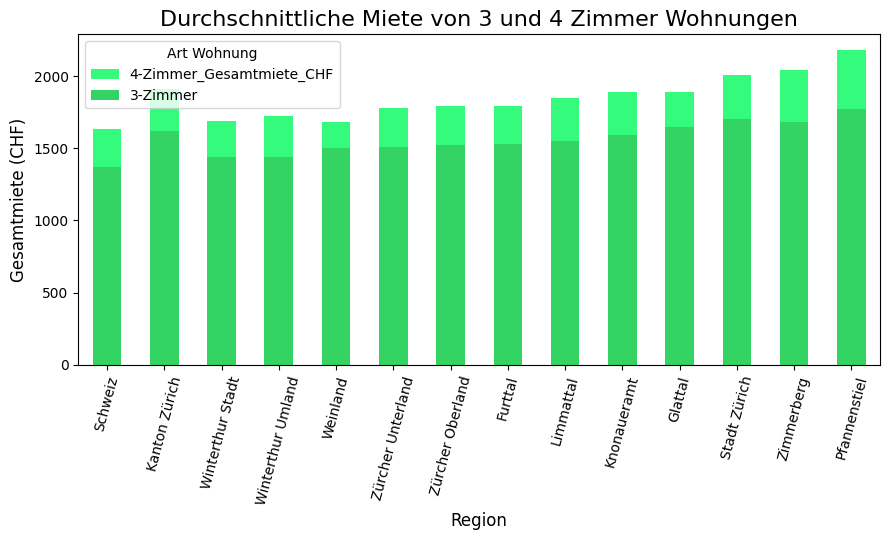

In [18]:
df_Miet_Selekt= df_Miet_alles[["Region", "3-Zimmer_Gesamtmiete_CHF", "4-Zimmer_Gesamtmiete_CHF"]]
df_Miet_Selekt = df_Miet_Selekt.set_index('Region')

ax = df_Miet_Selekt['4-Zimmer_Gesamtmiete_CHF'].plot(
    kind='bar', 
    figsize=(9, 5.5),
    rot=90,
    color=["#35fb7c"]
)

df_Miet_Selekt['3-Zimmer_Gesamtmiete_CHF'].plot(
    kind='bar', 
    ax=ax,
    rot=75, 
    color="#33d463",
    label='3-Zimmer'
)

plt.title('Durchschnittliche Miete von 3 und 4 Zimmer Wohnungen', fontsize=16)
plt.ylabel('Gesamtmiete (CHF)', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.legend(title='Art Wohnung')

plt.tight_layout()
plt.show()